## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)

## 2. Baca Dataset

In [5]:
df = pd.read_excel("CADalizadeh.xls")

## 3. EDA

Dimensi (baris, kolom): (303, 56)
Jumlah atribut (kolom): 56
Jumlah data (baris): 303

Contoh 5 baris awal:


,No,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,Obesity,CRF,CVA,Airway disease,Thyroid Disease,CHF,DLP,BP,PR,Edema,Weak Peripheral Pulse,Lung rales,Systolic Murmur,Diastolic Murmur,Typical Chest Pain,Dyspnea,Function Class,Atypical,Nonanginal,Exertional CP,LowTH Ang,Q Wave,St Elevation,St Depression,Tinversion,LVH,Poor R Progression,FBS,CR,TG,LDL,HDL,BUN,ESR,HB,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,1,53,90,175,Male,29.387755,0,1,1,0,0,Y,N,N,N,N,N,Y,110,80,0,N,N,N,N,0,N,0,N,N,N,N,0,0,1,1,N,N,90,0.7,250,155,30.0,8,7,15.6,4.7,141,5700,39,52,261,50,0,N,0
1,2,67,70,157,Female,28.398718,0,1,0,0,0,Y,N,N,N,N,N,N,140,80,1,N,N,N,N,1,N,0,N,N,N,N,0,0,1,1,N,N,80,1.0,309,121,36.0,30,26,13.9,4.7,156,7700,38,55,165,40,4,N,0
2,3,54,54,164,Male,20.077335,0,0,1,0,0,N,N,N,N,N,N,N,100,100,0,N,N,N,N,1,N,0,N,N,N,N,0,0,0,0,N,N,85,1.0,103,70,45.0,17,10,13.5,4.7,139,7400,38,60,230,40,2,mild,0
3,4,66,67,158,Female,26.838648,0,1,0,0,0,Y,N,N,N,N,N,N,100,80,0,N,N,N,Y,0,Y,3,N,Y,N,N,0,0,1,0,N,N,78,1.2,63,55,27.0,30,76,12.1,4.4,142,13000,18,72,742,55,0,Severe,1
4,5,50,87,153,Female,37.165193,0,1,0,0,0,Y,N,N,N,N,N,N,110,80,0,N,N,Y,N,0,Y,2,N,N,N,N,0,0,0,0,N,N,104,1.0,170,110,50.0,16,27,13.2,4.0,140,9200,55,39,274,50,0,Severe,1



Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 56 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   No                     303 non-null    int64  
 1   Age                    303 non-null    int64  
 2   Weight                 303 non-null    int64  
 3   Length                 303 non-null    int64  
 4   Sex                    303 non-null    str    
 5   BMI                    303 non-null    float64
 6   DM                     303 non-null    int64  
 7   HTN                    303 non-null    int64  
 8   Current Smoker         303 non-null    int64  
 9   EX-Smoker              303 non-null    int64  
 10  FH                     303 non-null    int64  
 11  Obesity                303 non-null    str    
 12  CRF                    303 non-null    str    
 13  CVA                    303 non-null    str    
 14  Airway disease         303 non-null    str    
 15  Th

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,303.0,NaN,NaN,NaN,152.0,87.612784,1.0,76.5,152.0,227.5,303.0
Age,303.0,NaN,NaN,NaN,58.89769,10.392278,30.0,51.0,58.0,66.0,86.0
Weight,303.0,NaN,NaN,NaN,73.831683,11.987358,48.0,65.0,74.0,81.0,120.0
Length,303.0,NaN,NaN,NaN,164.716172,9.327661,140.0,158.0,165.0,171.0,188.0
Sex,303,2,Male,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,303.0,NaN,NaN,NaN,27.248339,4.098865,18.115413,24.51438,26.77551,29.411765,40.900658
DM,303.0,NaN,NaN,NaN,0.29703,0.457706,0.0,0.0,0.0,1.0,1.0
HTN,303.0,NaN,NaN,NaN,0.590759,0.492507,0.0,0.0,1.0,1.0,1.0
Current Smoker,303.0,NaN,NaN,NaN,0.207921,0.406491,0.0,0.0,0.0,0.0,1.0
EX-Smoker,303.0,NaN,NaN,NaN,0.033003,0.178941,0.0,0.0,0.0,0.0,1.0



Jumlah missing value per kolom (top 20):


No                 0
Age                0
Weight             0
Length             0
Sex                0
BMI                0
DM                 0
HTN                0
Current Smoker     0
EX-Smoker          0
FH                 0
Obesity            0
CRF                0
CVA                0
Airway disease     0
Thyroid Disease    0
CHF                0
DLP                0
BP                 0
PR                 0
dtype: int64


Jumlah fitur numerik: 35
Jumlah fitur kategorikal: 20


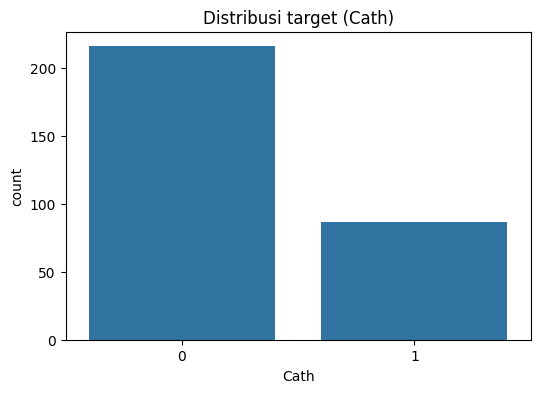

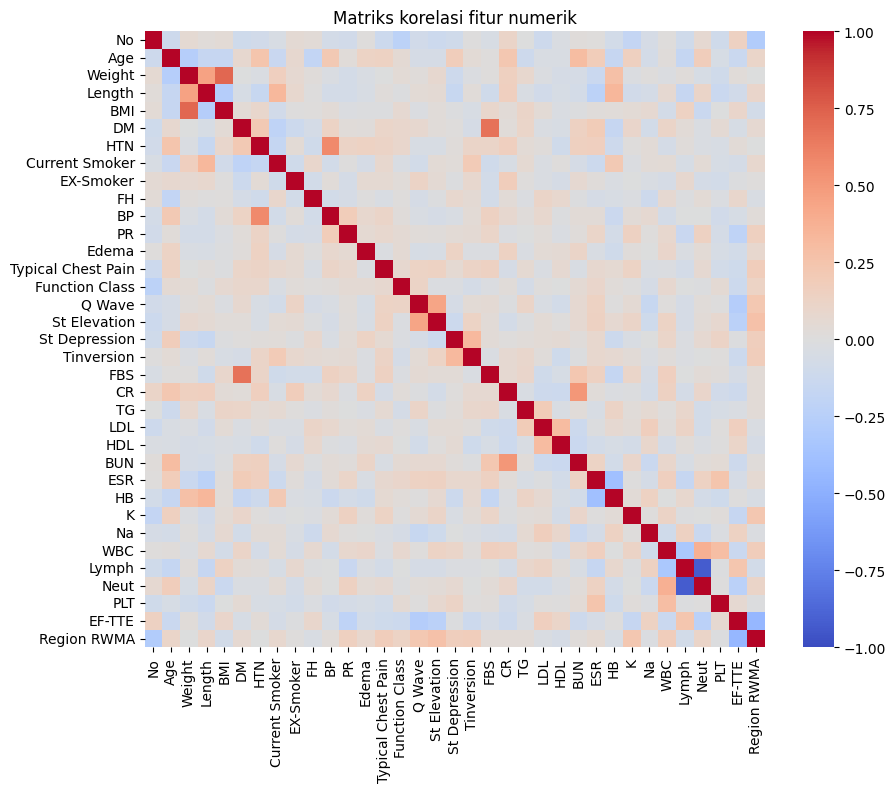

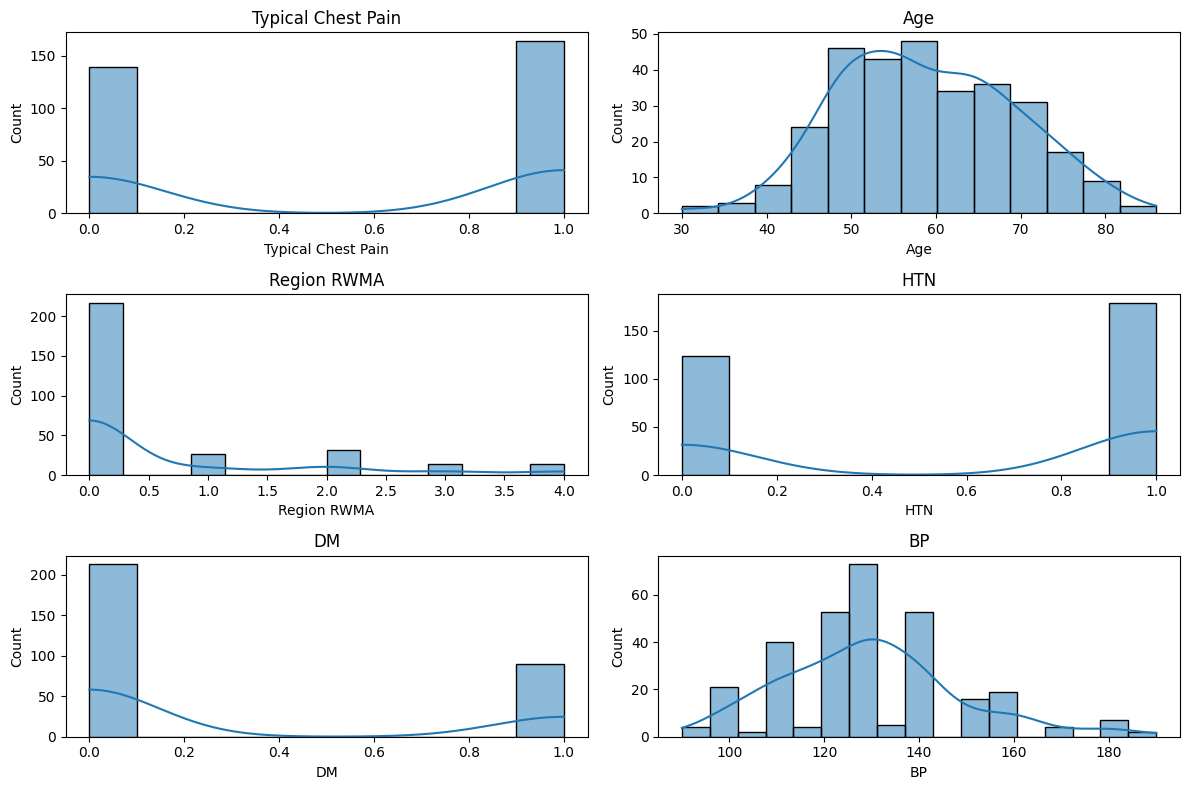

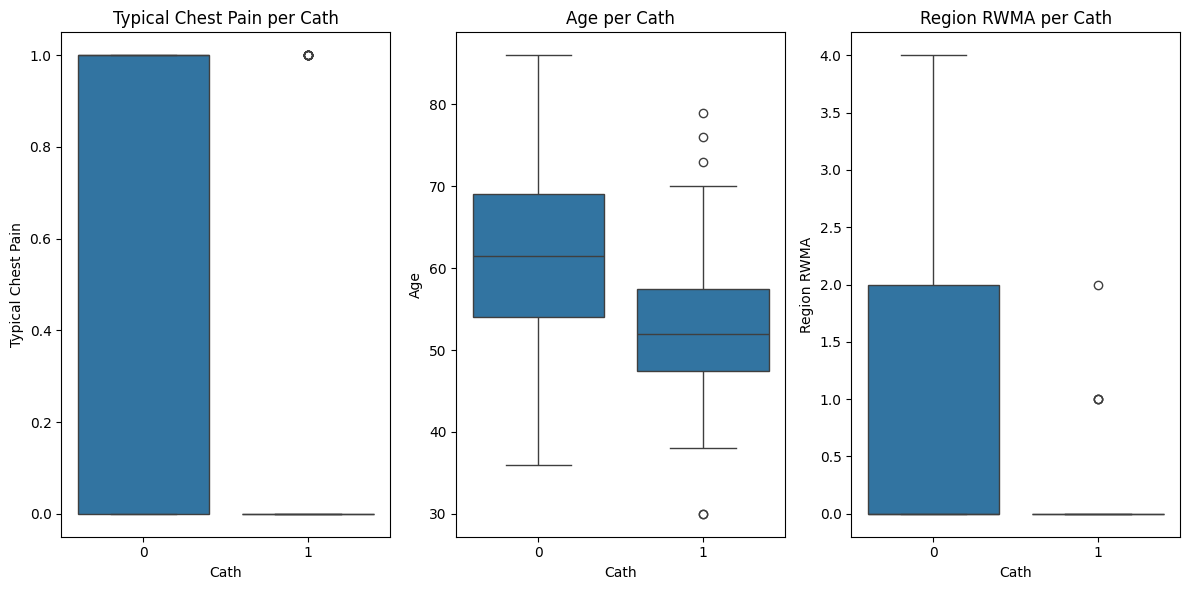

In [35]:
target = 'Cath'

data = df

print('Dimensi (baris, kolom):', data.shape)
print('Jumlah atribut (kolom):', data.shape[1])
print('Jumlah data (baris):', data.shape[0])

print('\nContoh 5 baris awal:')
display(data.head())

print('\nInfo dataset:')
data.info()

print('\nStatistik deskriptif semua kolom:')
display(data.describe(include='all').T)

print('\nJumlah missing value per kolom (top 20):')
display(data.isna().sum().sort_values(ascending=False).head(20))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target in num_cols:
    num_cols.remove(target)

cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
if target in cat_cols:
    cat_cols.remove(target)

print('\nJumlah fitur numerik:', len(num_cols))
print('Jumlah fitur kategorikal:', len(cat_cols))

if target in data.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[target].astype(str))
    plt.title(f'Distribusi target ({target})')
    plt.show()

corr_target = pd.Series(dtype=float)
if len(num_cols) >= 1 and target in data.columns:
    y_enc = LabelEncoder().fit_transform(data[target].astype(str))
    df_corr = data[num_cols].copy()
    df_corr['__target_enc'] = y_enc
    corr_target = df_corr.corr()['__target_enc'].drop('__target_enc').abs().sort_values(ascending=False)

if len(num_cols) >= 2:
    plt.figure(figsize=(10,8))
    sns.heatmap(data[num_cols].corr(), cmap='coolwarm', center=0, vmax=1, vmin=-1)
    plt.title('Matriks korelasi fitur numerik')
    plt.show()

top_feats = corr_target.head(6).index.tolist() if not corr_target.empty else []
if top_feats:
    plt.figure(figsize=(12,8))
    for i, col in enumerate(top_feats, 1):
        plt.subplot(3,2,i)
        sns.histplot(data[col].dropna(), kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()

if len(top_feats) >= 3:
    plt.figure(figsize=(12,6))
    for i, col in enumerate(top_feats[:3], 1):
        plt.subplot(1,3,i)
        sns.boxplot(x=data[target].astype(str), y=data[col])
        plt.title(f'{col} per {target}')
    plt.tight_layout()
    plt.show()

## 4. Supervised Learning

In [25]:
df = df.drop_duplicates()
df = df.dropna()

le = LabelEncoder()
df[target] = le.fit_transform(df[target].astype(str))

X = df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')
if 'No' in X.columns:
    X = X.drop(columns=['No'])

y = df[target]

print('Ukuran X:', X.shape)
print('Ukuran y:', y.shape)
print('Kolom X:', X.columns.tolist())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'MLP': MLPClassifier(max_iter=500, random_state=42),
    'NaiveBayes': GaussianNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

import pandas as _pd
_pd.DataFrame(results).T

Ukuran X: (303, 34)
Ukuran y: (303,)
Kolom X: ['Age', 'Weight', 'Length', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'BP', 'PR', 'Edema', 'Typical Chest Pain', 'Function Class', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA']


Ukuran X: (303, 34)
Ukuran y: (303,)
Kolom X: ['Age', 'Weight', 'Length', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'BP', 'PR', 'Edema', 'Typical Chest Pain', 'Function Class', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA']


,accuracy,precision,recall,f1
RandomForest,0.828947,0.831405,0.828947,0.813534
MLP,0.828947,0.823503,0.828947,0.821767
NaiveBayes,0.434211,0.678360,0.434211,0.416010


## 5. Evaluasi

Classification Report - RandomForest
              precision    recall  f1-score   support

           0       0.83      0.96      0.89        54
           1       0.85      0.50      0.63        22

    accuracy                           0.83        76
   macro avg       0.84      0.73      0.76        76
weighted avg       0.83      0.83      0.81        76



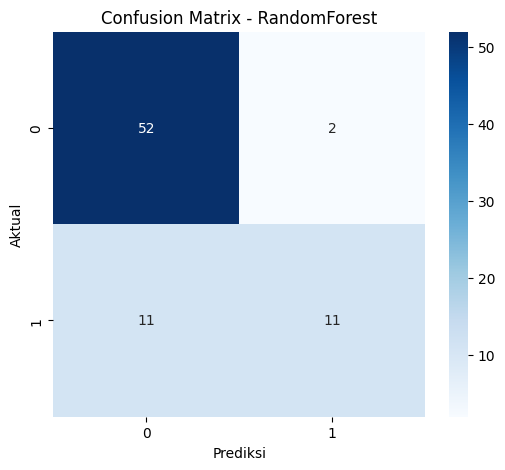

In [24]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - RandomForest')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RandomForest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Classification Report - MLP
              precision    recall  f1-score   support

           0       0.85      0.93      0.88        54
           1       0.76      0.59      0.67        22

    accuracy                           0.83        76
   macro avg       0.81      0.76      0.78        76
weighted avg       0.82      0.83      0.82        76



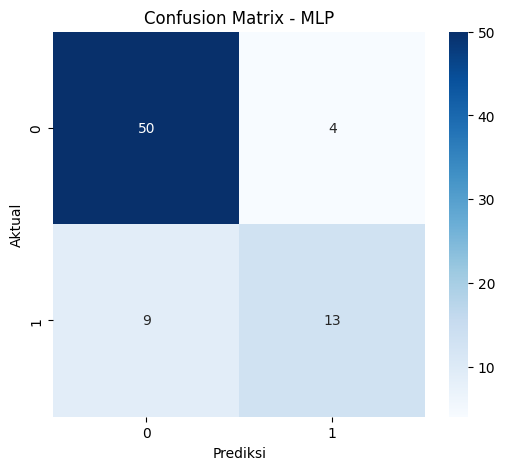

In [18]:
model = MLPClassifier(max_iter=500, random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - MLP')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MLP')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Classification Report - NaiveBayes
              precision    recall  f1-score   support

           0       0.82      0.26      0.39        54
           1       0.32      0.86      0.47        22

    accuracy                           0.43        76
   macro avg       0.57      0.56      0.43        76
weighted avg       0.68      0.43      0.42        76



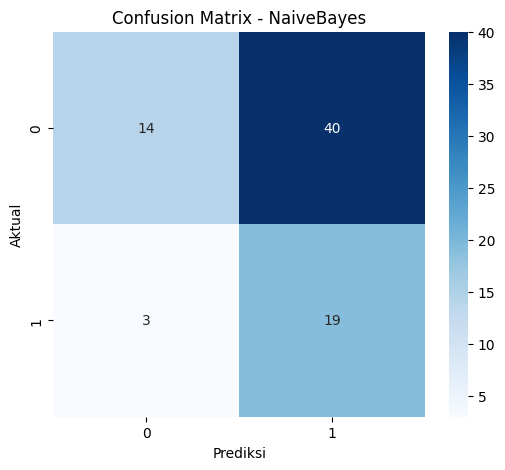

In [20]:
model = GaussianNB()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - NaiveBayes')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - NaiveBayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## 6. Unsupervised Learning: K-Means

In [ ]:
# STEP 1: Pilih fitur (semua kecuali target)
selected_features = [col for col in df.columns if col != 'Cath']

# STEP 2: One-Hot Encoding untuk fitur kategori
df_encoded = pd.get_dummies(df[selected_features], drop_first=True)

# STEP 3: Ambil nilai sebagai array
X = df_encoded.values

# STEP 4: Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Bentuk data setelah scaling:", X_scaled.shape)

# STEP 5: Analisis KMeans dengan berbagai k
k_range = range(2, 11)
sse_values, silhouette_scores, db_indices = elbow_method(X_scaled, k_range)

# STEP 6: Plot kurva elbow + metrik
plot_elbow_curve(k_range, sse_values, silhouette_scores, db_indices)

# STEP 7: Cetak hasil analisis
print("K Analysis:")
for i, k in enumerate(k_range):
    print(f"k={k}: SSE={sse_values[i]:.4f}, Silhouette={silhouette_scores[i]:.4f}, DB={db_indices[i]:.4f}")